### Exercice 1 : Détection et suppression des doublons

### Instructions

### Objectif : Identifier et supprimer les entrées en double dans l'ensemble de données sur le Titanic.

Charger l'ensemble de données Titanic.
Identifiez les lignes en double en vous basant sur toutes les colonnes.
Supprimez les lignes en double présentes dans l'ensemble de données.
Vérifiez la suppression des doublons en comparant le nombre de lignes avant et après la suppression.



  NB : Conseil : Utilisez les fonctions duplicated()`and` drop_duplicates()de Pandas.


## Réponse

### Version du programme

In [1]:
import pandas as pd
    


In [3]:
    # Chargement du dataset
    df = pd.read_csv("dataset/train.csv")

    # Nombre de lignes avant suppression
    print("Nombre de lignes avant suppression :", len(df))

    # Détection des doublons
    doublons = df.duplicated()

    # Nombre de doublons
    print("Nombre de doublons :", doublons.sum())

    # Suppression des doublons
    df_sans_doublons = df.drop_duplicates()

    # Nombre de lignes après suppression
    print("Nombre de lignes après suppression :", len(df_sans_doublons))

Nombre de lignes avant suppression : 891
Nombre de doublons : 0
Nombre de lignes après suppression : 891


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S






##


##

## Exercice 2 : Gestion des valeurs manquantes
### Instructions

Identifier les colonnes du jeu de données Titanic comportant des valeurs manquantes.
Explorez différentes stratégies pour gérer les données manquantes, telles que la suppression, l'imputation et le remplissage par une valeur constante.
Appliquez chaque stratégie à différentes colonnes en fonction de la nature des données.
Conseil : Consultez les méthodes comme dropna(), fillna(), et SimpleImputerde scikit-learn.


## Réponse

In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer

# Charger les données
df = pd.read_csv('dataset/train.csv')

# Étape 1: Supprimer Cabin 
df = df.drop('Cabin', axis=1)

# Étape 2: Imputer Age avec la médiane
imputer_age = SimpleImputer(strategy='median')
df['Age'] = imputer_age.fit_transform(df[['Age']])

# Étape 3: Imputer Fare avec la médiane
imputer_fare = SimpleImputer(strategy='median')
df['Fare'] = imputer_fare.fit_transform(df[['Fare']])

# Étape 4: Imputer Embarked avec la mode
imputer_emb = SimpleImputer(strategy='most_frequent')
df['Embarked'] = imputer_emb.fit_transform(df[['Embarked']]).flatten()

# Vérifier le résultat
print(df.isnull().sum())  # Devrait afficher 0 pour toutes les colonnes
print(df.shape)  # 891 lignes, 11 colonnes

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64
(891, 11)



##




##

##  Exercice 3 : Ingénierie des fonctionnalités
### Instructions

Créez de nouvelles fonctionnalités, telles que Family Size« fromSibSp » Parchet Title« extracted » de la Namecolonne.
Convertissez les variables catégorielles en format numérique à l'aide de techniques telles que l'encodage one-hot ou l'encodage par étiquette.
Vous encoderez ici de nouvelles caractéristiques catégorielles (comme le titre), mais ne mettez pas encore à l'échelle les caractéristiques numériques — cela viendra après le traitement des valeurs aberrantes.
Conseil : Utilisez Pandas pour la manipulation des données et le module de prétraitement de scikit-learn pour l’encodage.

##




##

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder



# 1. Chargement du dataset

df = pd.read_csv("dataset/train.csv")

# 2. Création de la variable FamilySize

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

print("Nouvelle variable FamilySize créée.")
print(df[["SibSp", "Parch", "FamilySize"]].head())


# 3. Extraction du titre depuis la colonne Name

df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.")

print("\nTitres extraits :")
print(df["Title"].head())


# 4. Vérification des titres uniques

print("\nTitres uniques dans le dataset :")
print(df["Title"].unique())



# 5. Encodage des variables catégorielles

# A. Encodage Label Encoding pour Title


# Le Label Encoder transforme les catégories en nombres

label_encoder = LabelEncoder()

df["Title_Encoded"] = label_encoder.fit_transform(df["Title"])

print("\nEncodage des titres :")
print(df[["Title", "Title_Encoded"]].head())


# 6. One-Hot Encoding pour Sex et Embarked


# get_dummies() crée une colonne par catégorie

df = pd.get_dummies(
    df,
    columns=["Sex", "Embarked"],
    drop_first=True
)

print("\nDataset après One-Hot Encoding :")
print(df.head())


# 7. Vérification finale des nouvelles variables


print("\nColonnes du dataset :")
print(df.columns)

Nouvelle variable FamilySize créée.
   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1

Titres extraits :
0      Mr
1     Mrs
2    Miss
3     Mrs
4      Mr
Name: Title, dtype: object

Titres uniques dans le dataset :
['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'the Countess' 'Jonkheer']

Encodage des titres :
  Title  Title_Encoded
0    Mr             11
1   Mrs             12
2  Miss              8
3   Mrs             12
4    Mr             11

Dataset après One-Hot Encoding :
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris 


##





##

#### Exercice 4 : Détection et traitement des valeurs aberrantes

#### Objectif : Détecter et limiter ou transformer les valeurs aberrantes dans des colonnes comme le prix et l'âge.

1. Visualisez les distributions à l'aide de diagrammes en boîte ou d'histogrammes pour identifier les valeurs aberrantes potentielles.
2. Utilisez les méthodes de l'écart interquartile (IQR) ou du score Z pour les détecter.
3. Traitez les valeurs aberrantes avec :

Plafonnement des quantiles (ex. 0,98)
Transformation du journal
Suppression de lignes
4. Comparez les données avant et après le traitement.

📌 Remarque : De légères différences entre les quantiles 0,98 et 0,99 sont normales lorsque les valeurs extrêmes sont rares ou très éloignées les unes des autres. Utilisez ces données df.quantile()pour explorer et choisir les seuils de manière empirique, en vous appuyant sur la visualisation.

Matplotlib is building the font cache; this may take a moment.


Aperçu du dataset :
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500

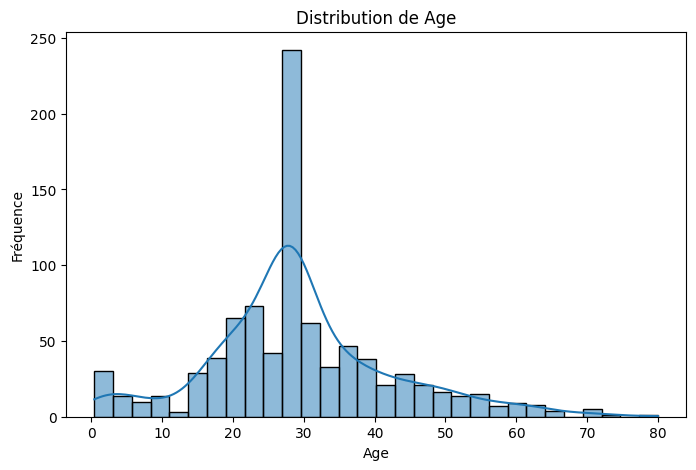

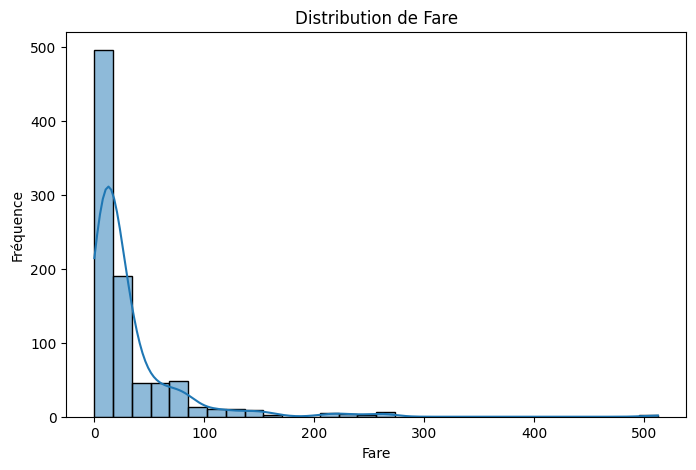

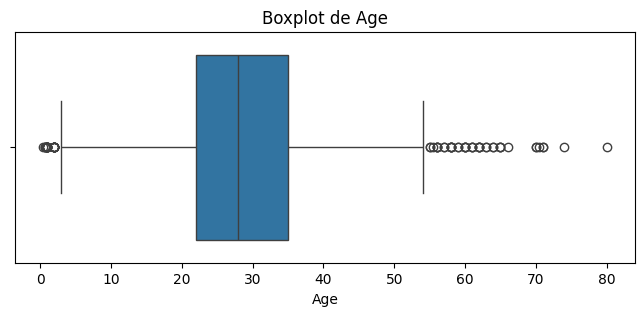

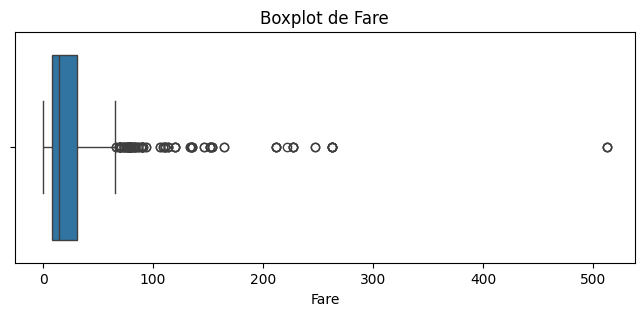


========== METHODE IQR ==========
Q1 : 7.9104
Q3 : 31.0
IQR : 23.0896
Borne inférieure : -26.724
Borne supérieure : 65.6344

Nombre d'outliers détectés avec IQR : 116

Exemples d'outliers :
        Fare
1    71.2833
27  263.0000
31  146.5208
34   82.1708
52   76.7292

========== QUANTILES ==========
0.95    112.07915
0.98    211.33750
0.99    249.00622
Name: Fare, dtype: float64

========== CAPPING ==========
      Fare  Fare_Capped
0   7.2500       7.2500
1  71.2833      71.2833
2   7.9250       7.9250
3  53.1000      53.1000
4   8.0500       8.0500


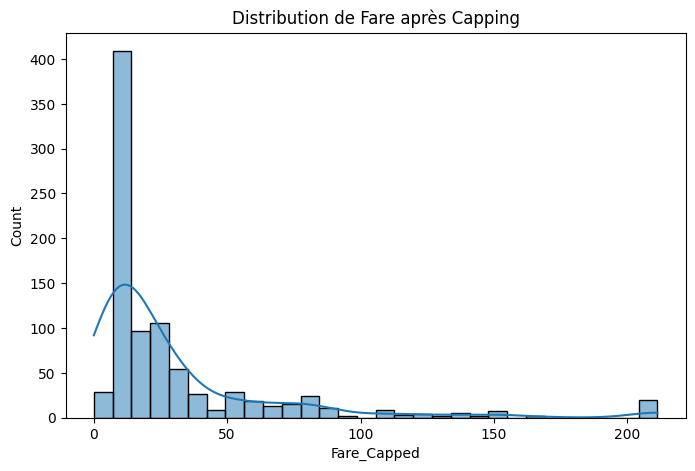


========== TRANSFORMATION LOG ==========
      Fare  Fare_Log
0   7.2500  2.110213
1  71.2833  4.280593
2   7.9250  2.188856
3  53.1000  3.990834
4   8.0500  2.202765


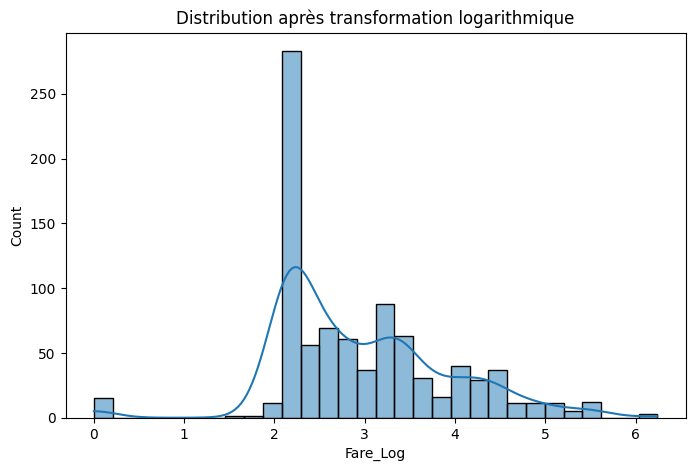


========== SUPPRESSION DES OUTLIERS ==========
Nombre de lignes avant suppression : 891
Nombre de lignes après suppression : 775
Nombre de lignes supprimées : 116

========== Z-SCORE ==========
      Fare  Fare_Zscore
0   7.2500    -0.502445
1  71.2833     0.786845
2   7.9250    -0.488854
3  53.1000     0.420730
4   8.0500    -0.486337

Nombre d'outliers détectés avec Z-score : 20

========== COMPARAISON ==========
Dataset original : (891, 15)
Dataset sans outliers : (775, 14)

Traitement des valeurs aberrantes terminé.


In [25]:
# REPONSE 4 : DETECTION ET TRAITEMENT DES VALEURS ABERRANTES
# Dataset : Titanic

# 1. IMPORTATION DES BIBLIOTHEQUES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore



# 2. CHARGEMENT DU DATASET
df = pd.read_csv("dataset/train.csv")

print("Aperçu du dataset :")
print(df.head())



# 3. VERIFICATION DES VALEURS MANQUANTES


# On vérifie les valeurs manquantes
# dans les colonnes numériques importantes

print("\nValeurs manquantes :")
print(df[["Age", "Fare"]].isnull().sum())



# 4. TRAITEMENT DES VALEURS MANQUANTES


# On remplace les valeurs manquantes de Age
# par la médiane car elle est robuste aux outliers

df["Age"].fillna(df["Age"].median(), inplace=True)

print("\nValeurs manquantes après traitement :")
print(df[["Age", "Fare"]].isnull().sum())



# 5. VISUALISATION DES DISTRIBUTIONS


# HISTOGRAMME AGE


plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Distribution de Age")
plt.xlabel("Age")
plt.ylabel("Fréquence")

plt.show()



# HISTOGRAMME FARE


plt.figure(figsize=(8,5))

sns.histplot(df["Fare"], bins=30, kde=True)

plt.title("Distribution de Fare")
plt.xlabel("Fare")
plt.ylabel("Fréquence")

plt.show()



# 6. BOXPLOTS POUR DETECTER LES OUTLIERS

# BOXPLOT AGE

plt.figure(figsize=(8,3))

sns.boxplot(x=df["Age"])

plt.title("Boxplot de Age")

plt.show()


# BOXPLOT FARE


plt.figure(figsize=(8,3))

sns.boxplot(x=df["Fare"])

plt.title("Boxplot de Fare")

plt.show()



# 7. DETECTION DES OUTLIERS AVEC LA METHODE IQR


# Calcul des quartiles

Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

# Calcul de l'IQR
IQR = Q3 - Q1

# Détermination des bornes

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

print("\n========== METHODE IQR ==========")

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)

print("Borne inférieure :", borne_inf)
print("Borne supérieure :", borne_sup)


#=========================================================
# 8. IDENTIFICATION DES OUTLIERS
#========================================================

outliers_iqr = df[
    (df["Fare"] < borne_inf) |
    (df["Fare"] > borne_sup)
]

print("\nNombre d'outliers détectés avec IQR :",
      len(outliers_iqr))

print("\nExemples d'outliers :")
print(outliers_iqr[["Fare"]].head())


#=========================================================
# 9. ANALYSE DES QUANTILES
#========================================================

print("\n========== QUANTILES ==========")

print(df["Fare"].quantile([0.95, 0.98, 0.99]))


#=========================================================
# 10. TRAITEMENT PAR PLAFONNEMENT (CAPPING)
#========================================================

# Le but est de limiter les valeurs extrêmes
# sans supprimer les lignes

seuil_98 = df["Fare"].quantile(0.98)

df["Fare_Capped"] = np.where(
    df["Fare"] > seuil_98,
    seuil_98,
    df["Fare"]
)

print("\n========== CAPPING ==========")

print(df[["Fare", "Fare_Capped"]].head())


#=========================================================
# 11. VISUALISATION APRES CAPPING
#========================================================

plt.figure(figsize=(8,5))

sns.histplot(df["Fare_Capped"], bins=30, kde=True)

plt.title("Distribution de Fare après Capping")

plt.xlabel("Fare_Capped")

plt.show()


#=========================================================
# 12. TRANSFORMATION LOGARITHMIQUE
#========================================================

# La transformation logarithmique réduit
# l'effet des très grandes valeurs

df["Fare_Log"] = np.log1p(df["Fare"])

print("\n========== TRANSFORMATION LOG ==========")

print(df[["Fare", "Fare_Log"]].head())


#========================================================
# 13. VISUALISATION APRES LOG TRANSFORMATION
#========================================================

plt.figure(figsize=(8,5))

sns.histplot(df["Fare_Log"], bins=30, kde=True)

plt.title("Distribution après transformation logarithmique")

plt.xlabel("Fare_Log")

plt.show()


#=========================================================
# 14. SUPPRESSION DES OUTLIERS
#========================================================

# Ici on supprime les lignes considérées
# comme aberrantes selon l'IQR

df_sans_outliers = df[
    (df["Fare"] >= borne_inf) &
    (df["Fare"] <= borne_sup)
]

print("\n========== SUPPRESSION DES OUTLIERS ==========")

print("Nombre de lignes avant suppression :", len(df))

print("Nombre de lignes après suppression :",
      len(df_sans_outliers))

print("Nombre de lignes supprimées :",
      len(df) - len(df_sans_outliers))


#=========================================================
# 15. DETECTION DES OUTLIERS AVEC LE Z-SCORE
#========================================================

# Le Z-score mesure le nombre
# d'écarts-types par rapport à la moyenne

df["Fare_Zscore"] = zscore(df["Fare"])

print("\n========== Z-SCORE ==========")

print(df[["Fare", "Fare_Zscore"]].head())


#=========================================================
# 16. DETECTION DES OUTLIERS VIA Z-SCORE
#========================================================

# Une valeur est souvent considérée
# comme aberrante si |Z| > 3

outliers_z = df[
    np.abs(df["Fare_Zscore"]) > 3
]

print("\nNombre d'outliers détectés avec Z-score :",
      len(outliers_z))


#=========================================================
# 17. COMPARAISON AVANT / APRES
#========================================================

print("\n========== COMPARAISON ==========")

print("Dataset original :", df.shape)

print("Dataset sans outliers :", df_sans_outliers.shape)


#=========================================================
# 18. CONCLUSION
#========================================================

print("\nTraitement des valeurs aberrantes terminé.")

##


###

#### Exercice 5 : Standardisation et normalisation des données
### Objectif : Mettre à l'échelle les caractéristiques numériques en vue de la modélisation.

Utilisez StandardScaler (moyenne = 0, écart-type = 1) pour les caractéristiques normalement distribuées.
Utilisez MinMaxScaler (plage [0, 1]) pour les caractéristiques asymétriques ou bornées.
📌 Important : Effectuez cette étape après le traitement des valeurs aberrantes afin d'éviter les distorsions causées par les valeurs extrêmes.

Aperçu du dataset :
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500

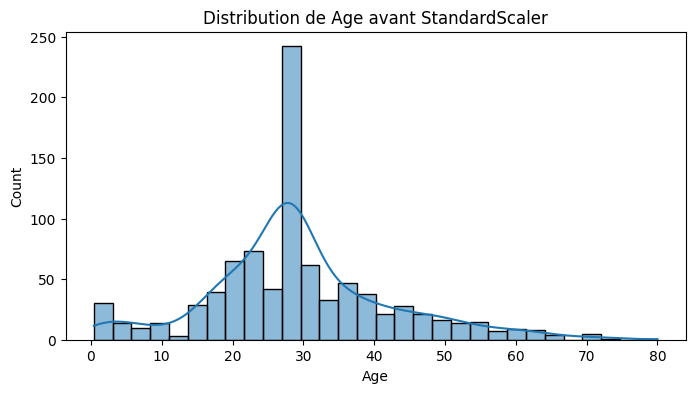

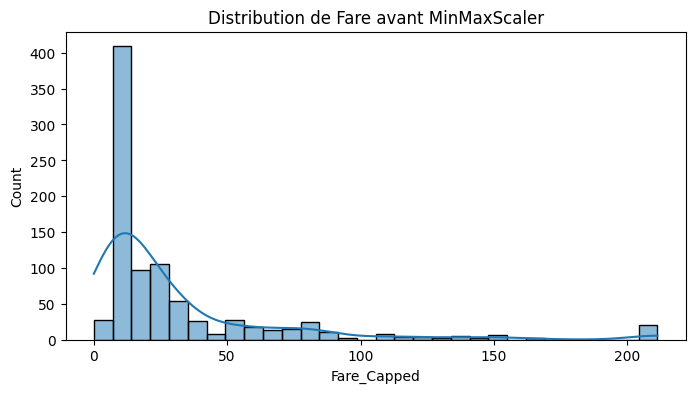


========== STANDARDISATION ==========
    Age  Age_Standardized
0  22.0         -0.565736
1  38.0          0.663861
2  26.0         -0.258337
3  35.0          0.433312
4  35.0          0.433312

========== NORMALISATION ==========
   Fare_Capped  Fare_Normalized
0       7.2500         0.034305
1      71.2833         0.337296
2       7.9250         0.037499
3      53.1000         0.251257
4       8.0500         0.038091

========== STATISTIQUES ==========

Statistiques Age_Standardized :
count    8.910000e+02
mean     2.272780e-16
std      1.000562e+00
min     -2.224156e+00
25%     -5.657365e-01
50%     -1.046374e-01
75%      4.333115e-01
max      3.891554e+00
Name: Age_Standardized, dtype: float64

Statistiques Fare_Normalized :
count    891.000000
mean       0.145163
std        0.188821
min        0.000000
25%        0.037430
50%        0.068394
75%        0.146685
max        1.000000
Name: Fare_Normalized, dtype: float64


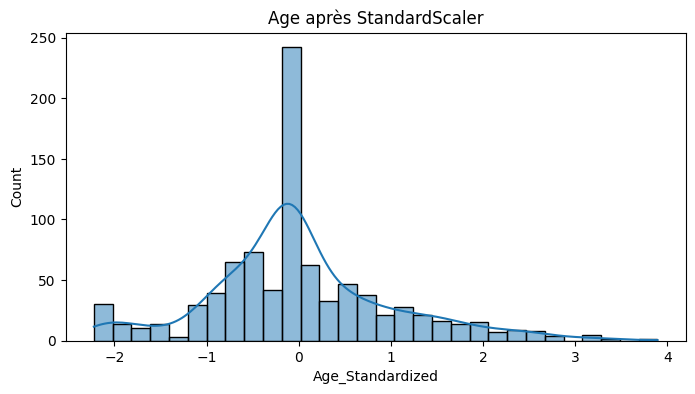

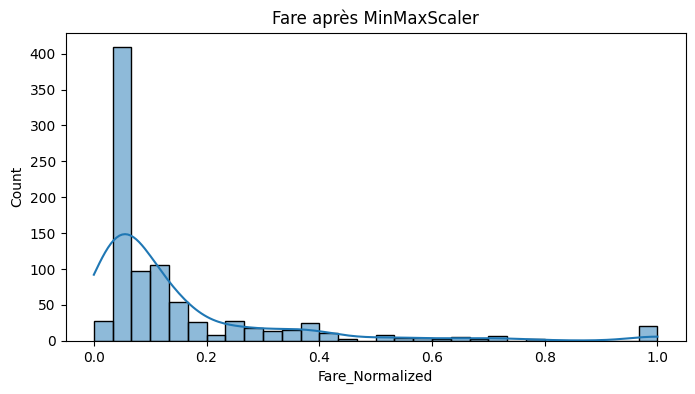


========== COMPARAISON ==========

Age avant scaling :
0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: Age, dtype: float64

Age après StandardScaler :
0   -0.565736
1    0.663861
2   -0.258337
3    0.433312
4    0.433312
Name: Age_Standardized, dtype: float64

Fare avant scaling :
0     7.2500
1    71.2833
2     7.9250
3    53.1000
4     8.0500
Name: Fare_Capped, dtype: float64

Fare après MinMaxScaler :
0    0.034305
1    0.337296
2    0.037499
3    0.251257
4    0.038091
Name: Fare_Normalized, dtype: float64

Mise à l'échelle terminée avec succès.


In [27]:

### REPONSE 5 : STANDARDISATION ET NORMALISATION
#### Dataset : Titanic



##### 1. IMPORTATION DES BIBLIOTHEQUES

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns


##### 2. CHARGEMENT DU DATASET


df = pd.read_csv("dataset/train.csv")

print("Aperçu du dataset :")
print(df.head())



##### 3. GESTION DES VALEURS MANQUANTES


#### Remplacement des valeurs manquantes de Age
#### par la médiane

df["Age"].fillna(df["Age"].median(), inplace=True)



##### 4. TRAITEMENT DES OUTLIERS SUR FARE


#### On applique un capping à 0.98
#### avant le scaling afin de réduire
#### l'influence des valeurs extrêmes

seuil_98 = df["Fare"].quantile(0.98)

df["Fare_Capped"] = np.where(
    df["Fare"] > seuil_98,
    seuil_98,
    df["Fare"]
)

print("\nValeur du seuil 0.98 :", seuil_98)



#### 5. VISUALISATION AVANT SCALING

#### DISTRIBUTION AGE


plt.figure(figsize=(8,4))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Distribution de Age avant StandardScaler")

plt.show()


#### DISTRIBUTION FARE_CAPPED


plt.figure(figsize=(8,4))

sns.histplot(df["Fare_Capped"], bins=30, kde=True)

plt.title("Distribution de Fare avant MinMaxScaler")

plt.show()



#### 6. STANDARDISATION AVEC STANDARDSCALER


### StandardScaler :
### moyenne = 0
### écart-type = 1

### Cette méthode est adaptée
### aux variables relativement normales

standard_scaler = StandardScaler()

df["Age_Standardized"] = standard_scaler.fit_transform(
    df[["Age"]]
)

print("\n========== STANDARDISATION ==========")

print(df[["Age", "Age_Standardized"]].head())



#### 7. NORMALISATION AVEC MINMAXSCALER


### MinMaxScaler ramène les valeurs
### entre 0 et 1

### Adapté aux distributions asymétriques

minmax_scaler = MinMaxScaler()

df["Fare_Normalized"] = minmax_scaler.fit_transform(
    df[["Fare_Capped"]]
)

print("\n========== NORMALISATION ==========")

print(df[["Fare_Capped", "Fare_Normalized"]].head())


#### 8. VERIFICATION DES RESULTATS


print("\n========== STATISTIQUES ==========")

### Vérification de Age standardisé
print("\nStatistiques Age_Standardized :")

print(df["Age_Standardized"].describe())


### Vérification de Fare normalisé
print("\nStatistiques Fare_Normalized :")

print(df["Fare_Normalized"].describe())


#### 9. VISUALISATION APRES STANDARDISATION


plt.figure(figsize=(8,4))

sns.histplot(df["Age_Standardized"], bins=30, kde=True)

plt.title("Age après StandardScaler")

plt.show()



#### 10. VISUALISATION APRES NORMALISATION


plt.figure(figsize=(8,4))

sns.histplot(df["Fare_Normalized"], bins=30, kde=True)

plt.title("Fare après MinMaxScaler")

plt.show()



#### 11. COMPARAISON AVANT / APRES

print("\n========== COMPARAISON ==========")

print("\nAge avant scaling :")
print(df["Age"].head())

print("\nAge après StandardScaler :")
print(df["Age_Standardized"].head())


print("\nFare avant scaling :")
print(df["Fare_Capped"].head())

print("\nFare après MinMaxScaler :")
print(df["Fare_Normalized"].head())



#### 12. CONCLUSION


print("\nMise à l'échelle terminée avec succès.")

##



###

#### Exercice 6 : Encodage des caractéristiques
### Objectif : Finaliser l'encodage des variables catégorielles.

 1. Identifier les colonnes catégorielles restantes (par exemple, Sexe, Embarquement, Titre).
2. Appliquer :

Encodage one-hot pour les variables nominales.
Encodage des étiquettes si des variables ordinales subsistent.

3. Fusionner les colonnes encodées avec l'ensemble de données principal.

📌 Rappel : L'encodage intervient après le traitement des valeurs manquantes et des valeurs aberrantes, mais avant la mise à l'échelle (le cas échéant).

In [ ]:

# 1. IMPORTATION DES BIBLIOTHEQUES

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder


# 2. CHARGEMENT DU DATASET


df = pd.read_csv("dataset/train.csv")

print("Aperçu du dataset :")
print(df.head())


# 3. GESTION DES VALEURS MANQUANTES


# AGE


# Remplacement des valeurs manquantes
# par la médiane

df["Age"].fillna(df["Age"].median(), inplace=True)



# Remplacement par la valeur la plus fréquente   

df["Embarked"].fillna(
    df["Embarked"].mode()[0],
    inplace=True
)



# 4. FEATURE ENGINEERING : CREATION DE TITLE

# Extraction du titre depuis Name

df["Title"] = df["Name"].str.extract(
    r",\s*([^\.]+)\."
)

print("\nTitres détectés :")
print(df["Title"].unique())




##





##

#### Exercise 7: Data Transformation for Age Feature
### Goal: Create and encode age groups.

Use pd.cut() to create bins for life stages (e.g. child, teen, adult, senior).
Apply one-hot encoding using pd.get_dummies().
📌 Example: You might define bins like [0, 12, 18, 60, 100] and label them accordingly.


In [ ]:
# 1. IMPORTATION DES BIBLIOTHEQUES

import pandas as pd


# 2. CHARGEMENT DU DATASET


df = pd.read_csv("dataset/train.csv")

print("Aperçu du dataset :")
print(df[["Age"]].head())



# 3. GESTION DES VALEURS MANQUANTES


# On remplace les valeurs manquantes par la médiane
# (robuste aux valeurs extrêmes)

df["Age"].fillna(df["Age"].median(), inplace=True)


# 4. CREATION DES GROUPES D'AGE (BINNING)


# Définition des intervalles
bins = [0, 12, 18, 60, 100]

# Labels associés aux intervalles
labels = ["Child", "Teen", "Adult", "Senior"]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print("\nExemple Age_Group :")
print(df[["Age", "Age_Group"]].head(10))



# 5. VERIFICATION DES DISTRIBUTIONS


print("\nRépartition des groupes d'âge :")
print(df["Age_Group"].value_counts())


# 6. ENCODAGE ONE-HOT DES GROUPES D'AGE


df_encoded = pd.get_dummies(
    df,
    columns=["Age_Group"],
    drop_first=False
)

print("\nDataset après encodage Age_Group :")
print(df_encoded.head())


# 7. COMPARAISON AVANT / APRES


print("\n========== COMPARAISON ==========")

print("\nAvant transformation :")
print(df[["Age"]].head())

print("\nAprès transformation :")
age_cols = [col for col in df_encoded.columns if "Age_Group" in col]
print(df_encoded[age_cols].head())



# 8. CONCLUSION


print("\nTransformation de Age terminée avec succès.")